plot 2

- Separate plot: Subset 30 neurons and add regression line for each of them (number of points per neuron in the regression = number of images). If messy, decrease to 10 neurons

plot 3

- Separate plot: all neurons: histogram = distribution of regression slopes (number of points = number of neurons)

plot 4

- Now combined plot: plot as kernel density all distribution of slopes for each sigmaXnoise condition (6 lines)
- all neurons

#### environment

In [2]:
import os 
import numpy as np
from numpy import full
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
#from predict_loop_functions import predict_loop, noise_iterations 
#from predict_loop_functions import filter_region, line_plot_mean, five_turning_curves, spike_plot_4x2
from scipy.stats import linregress

In [3]:
# use image stack from july16 already saved
image_stack = np.load('saved_inputs_outputs//image_stack_july16.npy')

In [ ]:
neurons = np.array([1685,368,1571,670,1918,1231,6795,6492,2507,1444,2361,6699,6672,6790,6209,6699,
                    1447,5583,2237,2161,7217,5114,4321,4823,6822,5935,823,6501,6819,5782])

#### predictions

In [ ]:
d3_sum, d3_mean, d3_var, d3_labels = predict_loop('dynamic', image_stack, 3, [[4,7]])

In [ ]:
d15_sum, d15_mean, d15_var, d15_labels = predict_loop('dynamic', image_stack, 15, [[4,7]])

In [ ]:
d30_sum, d30_mean, d30_var, d30_labels = predict_loop('dynamic', image_stack, 30, [[4,7]])

In [ ]:
c3_sum, c3_mean, c3_var, c3_labels = predict_loop('constant', image_stack, 3, [[4,7]])

In [ ]:
c15_sum, c15_mean, c15_var, c15_labels = predict_loop('constant', image_stack, 15, [[4,7]])

In [ ]:
c30_sum, c30_mean, c30_var, c30_labels = predict_loop('constant', image_stack, 30, [[4,7]])

In [ ]:
dbin_sum, dbin_mean, dbin_var, dbin_labels = predict_loop('dynamic', image_stack, 0, [[4,7]], stochastic_bin_param = True)

In [ ]:
cbin_sum, cbin_mean, cbin_var, cbin_labels = predict_loop('constant', image_stack, 0, [[4,7]], stochastic_bin_param = True)

In [ ]:
# save predictions to predictions_july21
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin']:
    for type_output in ['_sum', '_mean', '_var', '_labels']:
        file_name = noise + type_output
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        np.save(path, arr = globals()[file_name])

##### add no noise prediction for turning curves

In [ ]:
no_noise_sum, no_noise_mean, no_noise_var, no_noise_labels = predict_loop('no noise', image_stack, 0, [[4,7]])

In [ ]:
for type in ['_sum', '_mean', '_var', '_labels']:
        file_name = 'no_noise' + type
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        np.save(path, arr = globals()[file_name])

#### load predictions

In [4]:
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
    for type_noise in ['_sum', '_mean', '_var', '_labels']:
        file_name = noise + type_noise + '.npy'
        var_name = noise + type_noise
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        globals()[var_name] = np.load(path)

In [5]:
# load predictions by region
for region in np.unique(d3_labels):
    for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
        for type_noise in ['_sum', '_mean', '_var']:
            file_name = noise + type_noise + '_r' + str(region) +  '.npy'
            path = 'saved_inputs_outputs//predictions_july21//' + file_name
            array_name = noise + type_noise + '_r' + str(region)
            globals()[array_name] = np.load(path)

#### remove_x()

In [25]:
def remove_x(arr, remove: str, k_percent: int):
    # Convert to NumPy array
    arr = np.array(arr)
    if len(arr) <= 1:
        return np.arange(len(arr))  # Return all indices for small arrays
    
    sort_indices = np.argsort(arr)
    
    n = len(arr)
    n_remove = int(k_percent / 100 * n)
    n_keep = max(1, n - n_remove)
    
    # Return indices to keep
    if remove == 'top':
        return sort_indices[:n_keep]
    else:  # remove == 'bottom'
        return sort_indices[-n_keep:]

#### plot 2

##### 30 random neurons for each region

In [9]:
# region 1
r1_randoms = np.random.randint(0, len(d3_mean_r1.flatten()-1), 30)
r1_randoms

array([15803,  5957, 24113,  3013, 13583,  7503, 25769, 11529, 14506,
        8391, 15132, 13036, 22055,  4813, 21485, 11690,  8168,  1449,
       26045, 24200, 10211,  1482, 22510, 23712, 20151, 24963,  9406,
       18197,   843,  4867])

In [21]:
r1_randoms = [15803,  5957, 24113,  3013, 13583,  7503, 25769, 11529, 14506,
        8391, 15132, 13036, 22055,  4813, 21485, 11690,  8168,  1449,
       26045, 24200, 10211,  1482, 22510, 23712, 20151, 24963,  9406,
       18197,   843,  4867]

In [11]:
# region 2
r2_randoms = np.random.randint(0, len(d3_mean_r2.flatten()-1), 30)
r2_randoms

array([4261, 1753, 4861, 1249, 1217, 4275, 2198, 4043,  386, 1649,  787,
        523, 4251, 3510, 3967, 1015, 2176, 3708, 3234,  505,  658, 2199,
       3412, 2196,   96, 1501, 2208, 4306, 1929,  823])

In [22]:
r2_randoms = [4261, 1753, 4861, 1249, 1217, 4275, 2198, 4043,  386, 1649,  787,
        523, 4251, 3510, 3967, 1015, 2176, 3708, 3234,  505,  658, 2199,
       3412, 2196,   96, 1501, 2208, 4306, 1929,  823]

In [16]:
# region 3
r3_randoms = np.random.randint(0, len(d3_mean_r3.flatten()-1), 30)
r3_randoms

array([1893,  655, 1332,  478,  729,  989,  752,  918, 1460, 1287,   43,
       1786, 1743,  255, 1565,  355,  297,  592, 1382, 1092,  518,  849,
       1911, 1005, 1794, 1326,  551,  819,  917,  284])

In [23]:
r3_randoms = [1893,  655, 1332,  478,  729,  989,  752,  918, 1460, 1287,   43,
       1786, 1743,  255, 1565,  355,  297,  592, 1382, 1092,  518,  849,
       1911, 1005, 1794, 1326,  551,  819,  917,  284]

In [18]:
# region 4
r4_randoms = np.random.randint(0, len(d3_mean_r4.flatten()-1), 30)
r4_randoms

array([4047,  361,  346, 2889,  923, 3534,  724, 1740, 1170, 3352,  580,
       3121,   79, 1327, 3318, 2208, 1617, 3617, 2345, 1055, 2454, 1413,
       3028,  687,  993, 2895,   95, 2323, 1111, 2079])

In [24]:
r4_randoms = [4047,  361,  346, 2889,  923, 3534,  724, 1740, 1170, 3352,  580,
       3121,   79, 1327, 3318, 2208, 1617, 3617, 2345, 1055, 2454, 1413,
       3028,  687,  993, 2895,   95, 2323, 1111, 2079]

##### plots

In [150]:
# plot 30 random neurons and put regression, make sure neurons is list of random neurons for each region
def mean_var_scatter_2x2_regression(means, vars, neurons, main_title: str, titles):
    means = [arr.flatten()[neurons] for arr in means]
    vars = [arr.flatten()[neurons] for arr in vars]    
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
    fig.text(0.5, 1.05, main_title, ha='center', va='top', fontsize=14)


    for i in range(2):
        for j in range(2):
            idx = i * 2 + j
            ax = axes[i, j]
            cmap = plt.get_cmap('viridis')
            colors = cmap(np.linspace(0, 1, len(neurons)))

            x = means[idx]
            y = vars[idx]

            for i_count, neuron in enumerate(neurons):
                ax.scatter(x[i_count], 
                            y[i_count],  
                            marker='^', color = colors[i_count])

            linregress_result = linregress(x, y)
            x_fit = np.linspace(np.min(x), np.max(x), len(x))
            y_fit = linregress_result.intercept + linregress_result.slope * x_fit

            ax.plot(x_fit, y_fit, color='red', label='Regression line', linewidth=2)

            se_fit = linregress_result.stderr * np.sqrt(1/len(x) + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
            ax.fill_between(x_fit, y_fit - 1.96 * se_fit, y_fit + 1.96 * se_fit, color='gray', alpha=0.3, label='95% CI')

            rsq = linregress_result.rvalue ** 2
            y = ax.get_ylim()[1]
            ax.text(1, y - 1 if y>1 else 1, f"Slope: {linregress_result.slope:.3f}\n95% CI: [{linregress_result.slope - 1.96*linregress_result.slope:.3f}, {linregress_result.slope + 1.96*linregress_result.stderr:.3f}]\nR²={rsq:.3f}", 
                    fontsize=8, verticalalignment='top')

            ax.set_title(titles[idx])
            ax.grid(True)
            ax.legend()
             # Label x-axis only for bottom plots (i == 1)
            if i == 1:
                ax.set_xlabel('Mean Predicted Spike Count')
            # Label y-axis only for left plots (j == 0)
            if j == 0:
                ax.set_ylabel('Variance in Predicted Spike Count')

    
    plt.tight_layout()
    plt.show()

In [105]:
region1_means = [d3_mean_r1, d15_mean_r1, d30_mean_r1, dbin_mean_r1]
region1_var = [d3_var_r1, d15_var_r1, d30_var_r1, dbin_var_r1]
randoms = r1_randoms
region1_titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

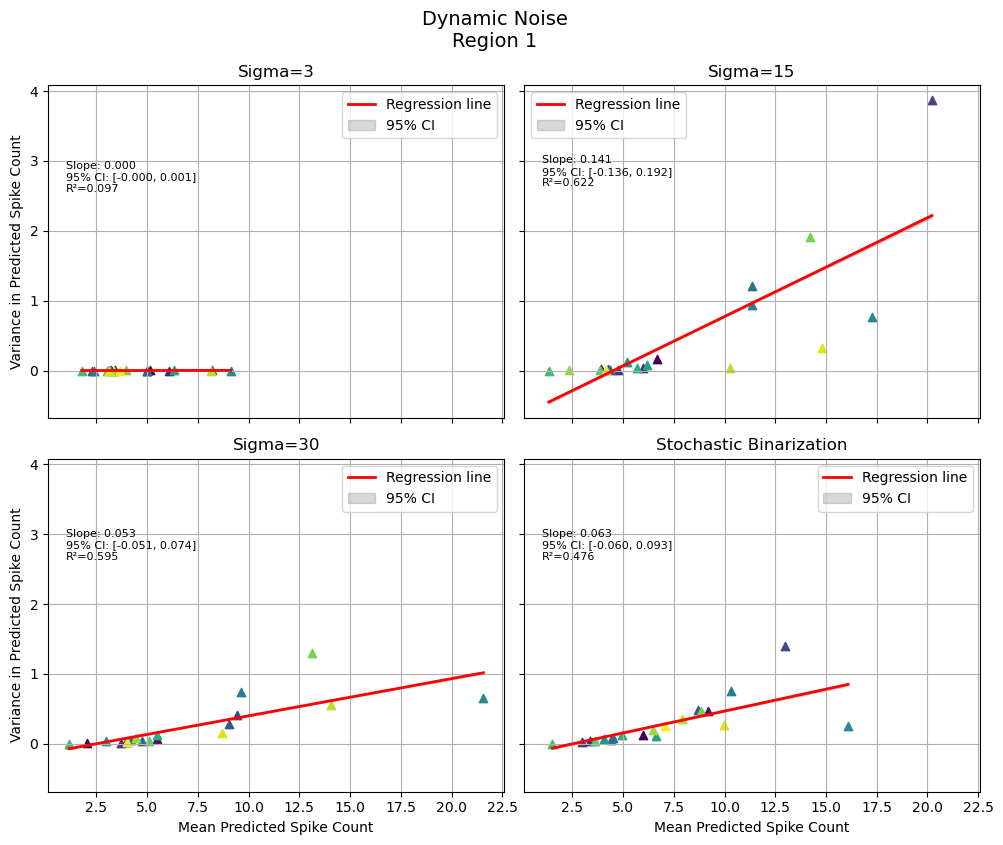

In [139]:
mean_var_scatter_2x2_regression(region1_means, region1_var, randoms[:20], 'Dynamic Noise\nRegion 1', region1_titles)

In [141]:
region1_means = [c3_mean_r1, c15_mean_r1, c30_mean_r1, cbin_mean_r1]
region1_var = [c3_var_r1, c15_var_r1, c30_var_r1, cbin_var_r1]
randoms = r1_randoms
titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

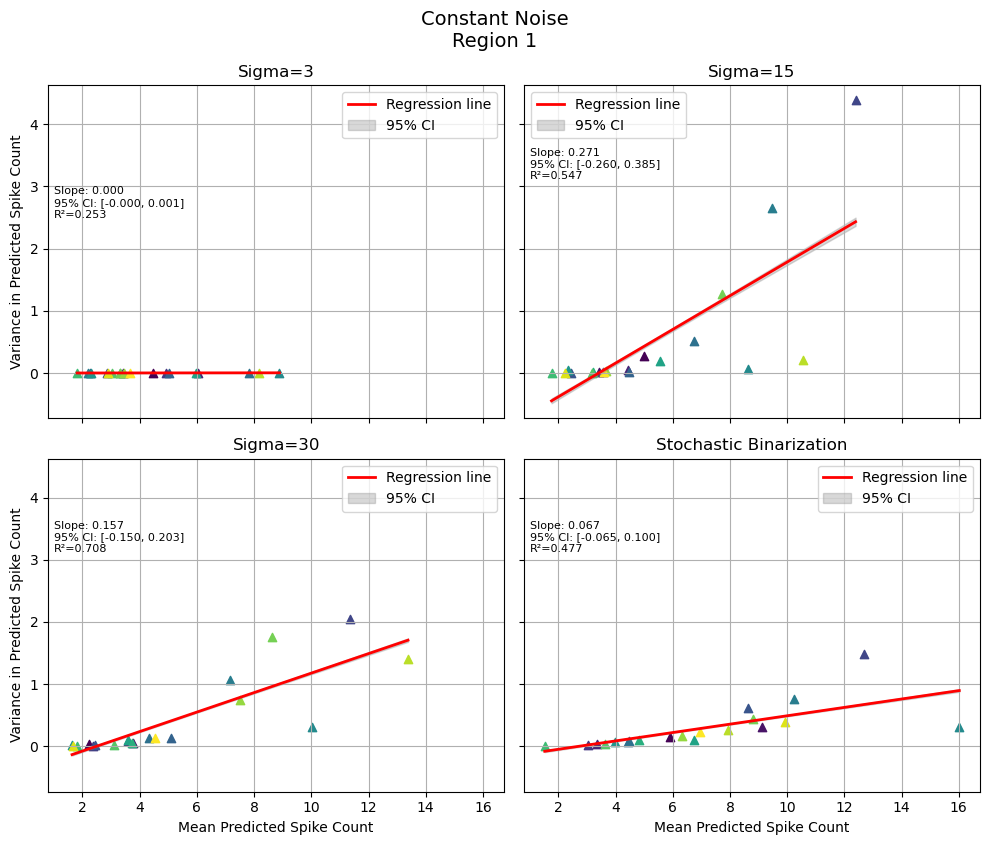

In [142]:
mean_var_scatter_2x2_regression(region1_means, region1_var, randoms[:20], 'Constant Noise\nRegion 1', region1_titles)

In [158]:
region2_means = [d3_mean_r2, d15_mean_r2, d30_mean_r2, dbin_mean_r2]
region2_var = [d3_var_r2, d15_var_r2, d30_var_r2, dbin_var_r2]
randoms = r2_randoms
titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

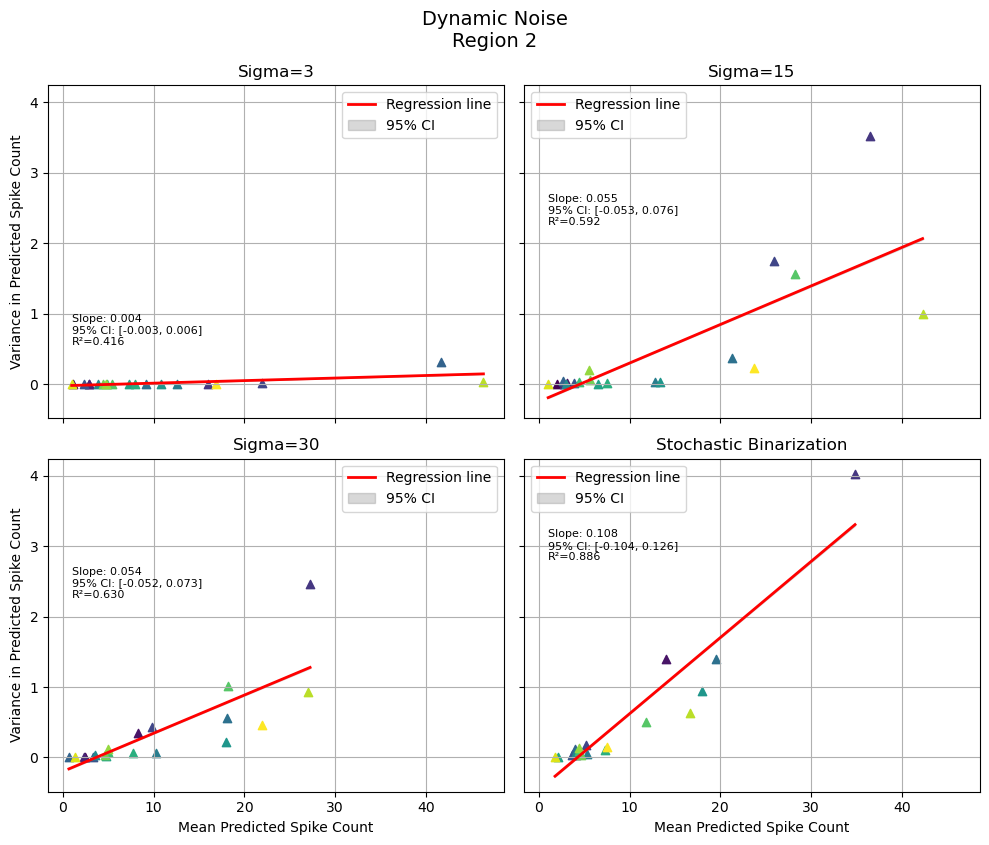

In [159]:
mean_var_scatter_2x2_regression(region2_means, region2_var, randoms[:20], 'Dynamic Noise\nRegion 2', titles)

In [145]:
region2_means = [c3_mean_r2, c15_mean_r2, c30_mean_r2, cbin_mean_r2]
region2_var = [c3_var_r2, c15_var_r2, c30_var_r2, cbin_var_r2]
randoms = r2_randoms
titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

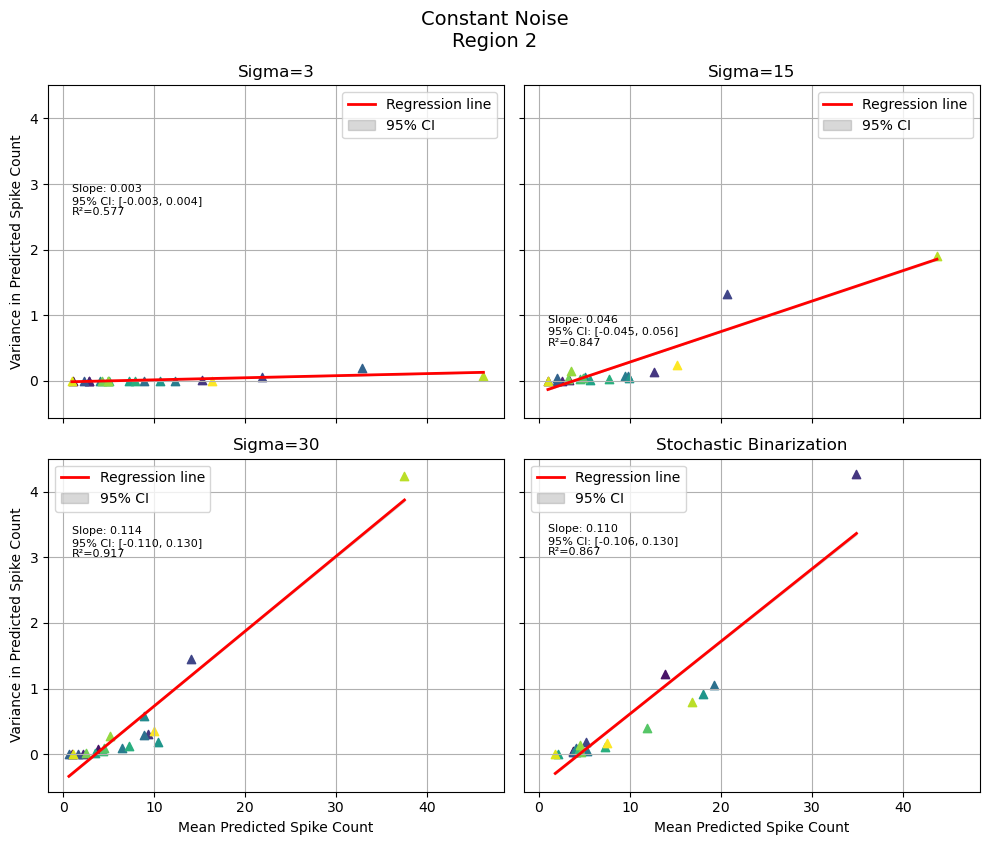

In [147]:
mean_var_scatter_2x2_regression(region2_means, region2_var, randoms[:20], 'Constant Noise\nRegion 2', titles)

In [148]:
region3_means = [d3_mean_r3, d15_mean_r3, d30_mean_r3, dbin_mean_r3]
region3_var = [d3_var_r3, d15_var_r3, d30_var_r3, dbin_var_r3]
randoms = r3_randoms
titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

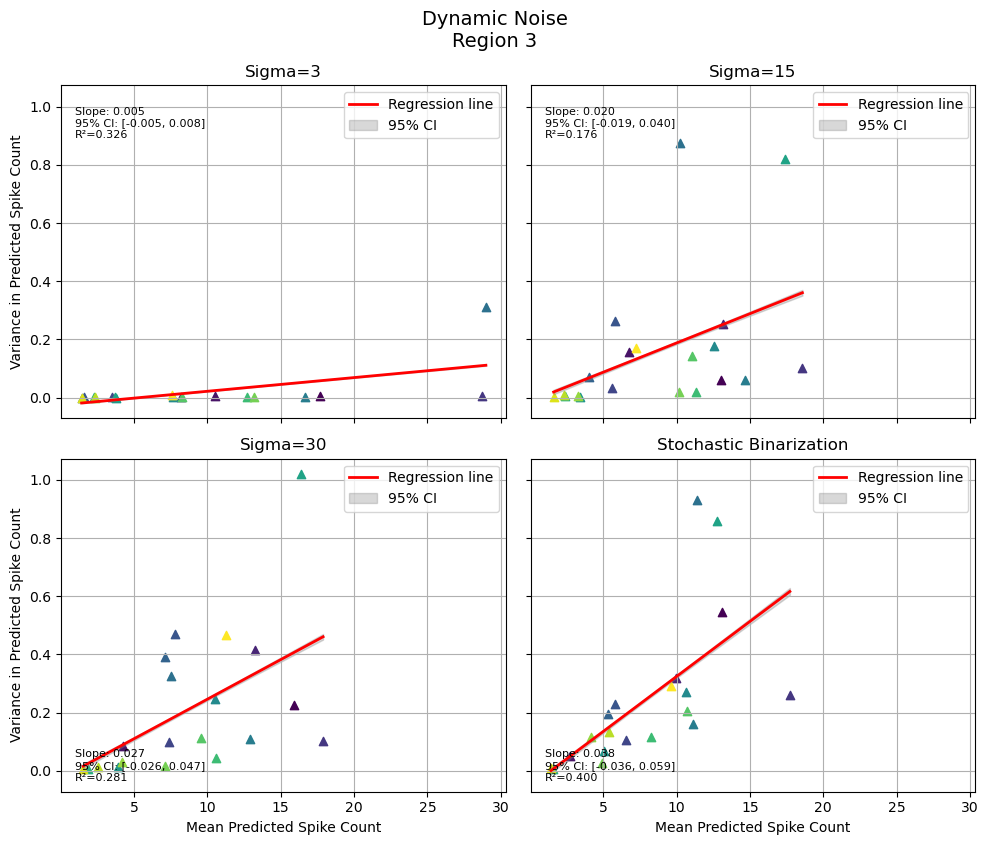

In [151]:
mean_var_scatter_2x2_regression(region3_means, region3_var, randoms[:20], 'Dynamic Noise\nRegion 3', titles)

In [152]:
region3_means = [c3_mean_r3, c15_mean_r3, c30_mean_r3, cbin_mean_r3]
region3_var = [c3_var_r3, c15_var_r3, c30_var_r3, cbin_var_r3]
randoms = r3_randoms
titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

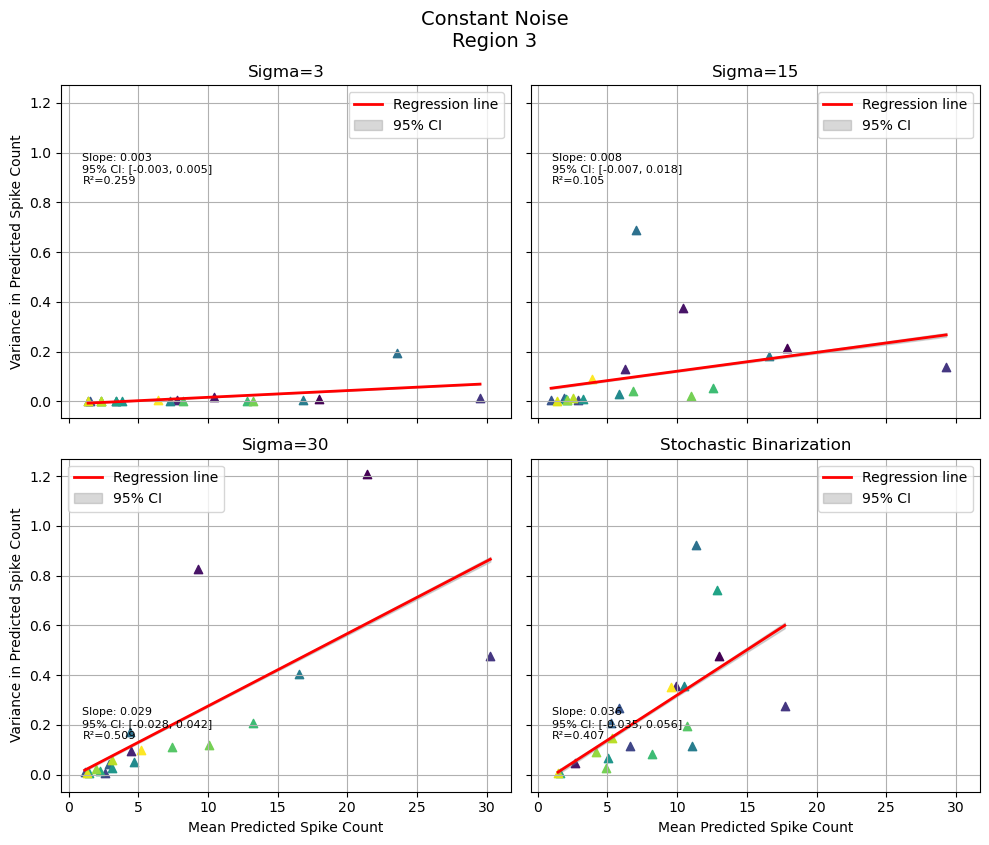

In [153]:
mean_var_scatter_2x2_regression(region3_means, region3_var, randoms[:20], 'Constant Noise\nRegion 3', titles)

In [154]:
region4_means = [d3_mean_r4, d15_mean_r4, d30_mean_r4, dbin_mean_r4]
region4_var = [d3_var_r4, d15_var_r4, d30_var_r4, dbin_var_r4]
randoms = r4_randoms
titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

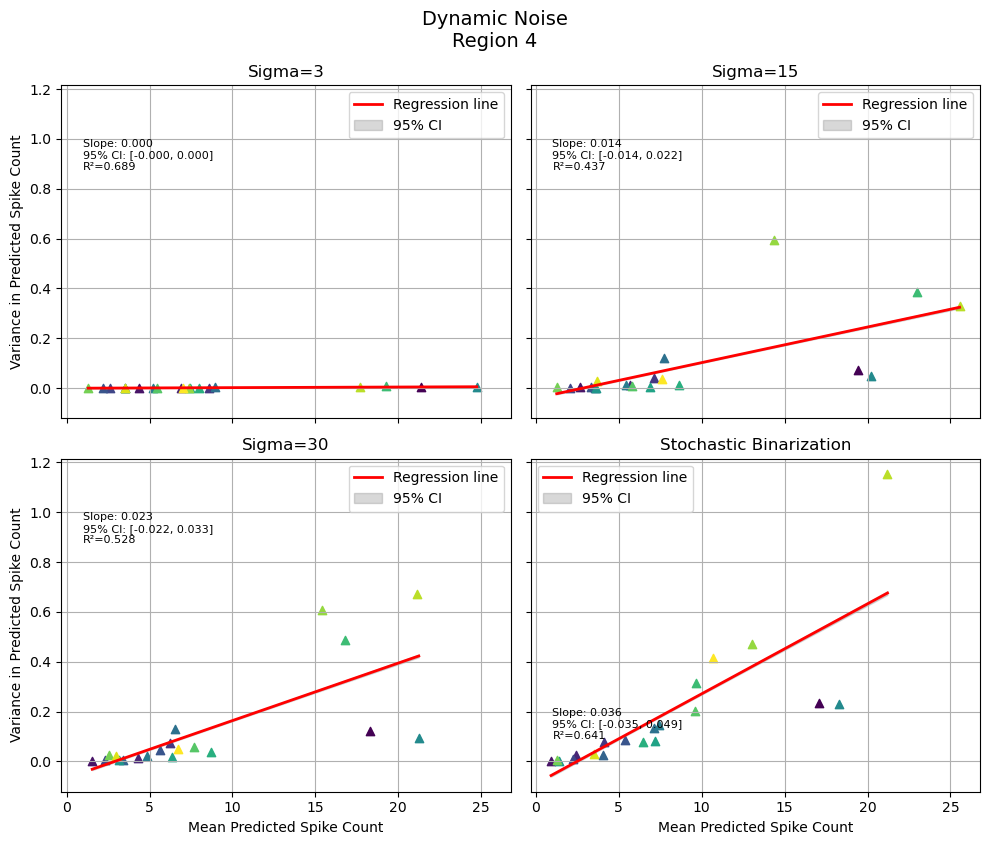

In [155]:
mean_var_scatter_2x2_regression(region4_means, region4_var, randoms[:20], 'Dynamic Noise\nRegion 4', titles)

In [156]:
region4_means = [c3_mean_r4, c15_mean_r4, c30_mean_r4, cbin_mean_r4]
region4_var = [c3_var_r4, c15_var_r4, c30_var_r4, cbin_var_r4]
randoms = r4_randoms
titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

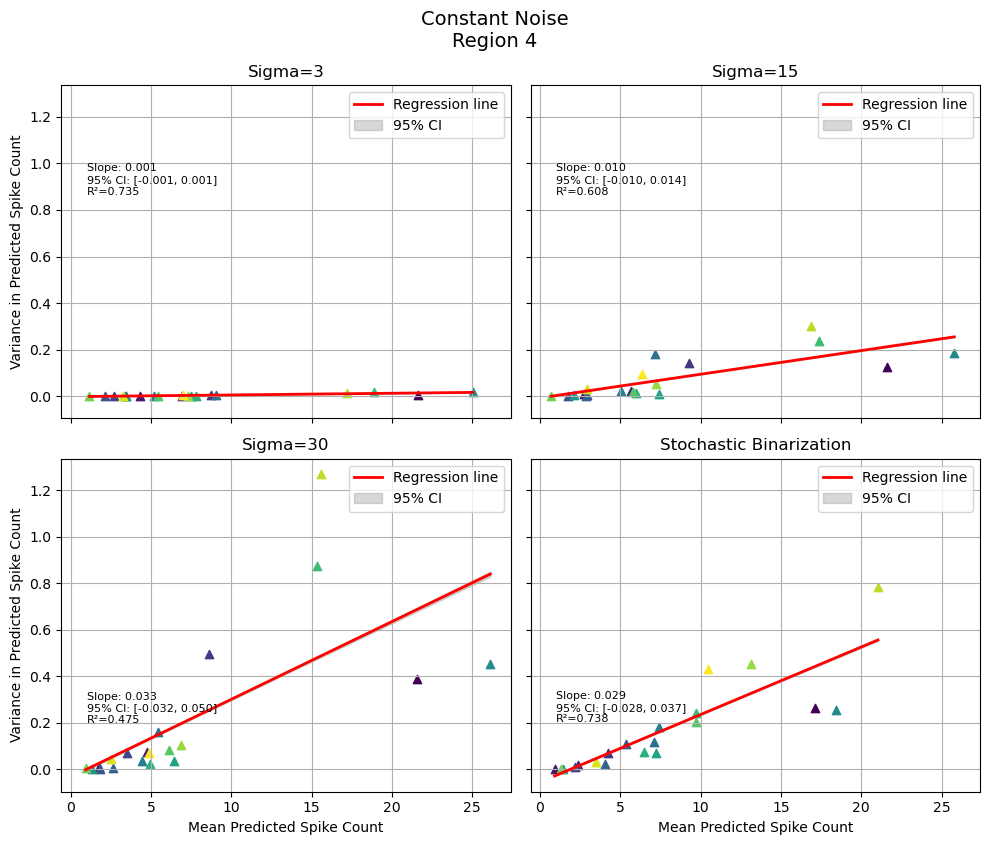

In [157]:
mean_var_scatter_2x2_regression(region4_means, region4_var, randoms[:20], 'Constant Noise\nRegion 4', titles)

#### plot 3